# Bayesian 기반 도로/차선 분석 과제 풀이

- 과제 노트북: `auto_class_2_BayesianClassifier.ipynb`
- 사용 sequence: **KITTI odometry sequence 09**
- 확인한 실제 데이터 경로: `D:\자율이동체\dataset`
- 실제 데이터 확인 결과: sequence 09 이미지 1591장, pose 1591개

데이터 구조는 다음을 가정한다.

`dataset/sequences/09/calib.txt`, `dataset/sequences/09/image_0/*.png`, `dataset/poses/09.txt` 구조를 사용한다.

노트북은 먼저 현재 폴더의 `dataset`을 찾고, 없으면 외장하드의 `D:\자율이동체\dataset`을 자동으로 사용한다.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter

try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

CANDIDATE_DATA_ROOTS = [Path("dataset"), Path(r"D:\자율이동체\dataset")]
DATA_ROOT = next((p for p in CANDIDATE_DATA_ROOTS if (p / "sequences" / "09").exists()), CANDIDATE_DATA_ROOTS[0])
SEQ = "09"
SEQ_DIR = DATA_ROOT / "sequences" / SEQ
IMG_DIR = SEQ_DIR / "image_0"
CALIB_PATH = SEQ_DIR / "calib.txt"
POSE_PATH = DATA_ROOT / "poses" / f"{SEQ}.txt"
OUT_DIR = Path("outputs") / "sequence_09_solution"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT.resolve())
print("CALIB:", CALIB_PATH.exists(), "POSE:", POSE_PATH.exists(), "cv2:", HAS_CV2)

In [2]:
def list_frames(img_dir=IMG_DIR):
    return sorted(img_dir.glob("*.png"))

def read_calib(path=CALIB_PATH):
    calib = {}
    if not path.exists():
        raise FileNotFoundError(f"calib.txt가 없습니다: {path}")
    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        key, values = line.split(":", 1)
        vals = np.array([float(v) for v in values.split()], dtype=float)
        if key.startswith("P"):
            calib[key] = vals.reshape(3, 4)
        elif key == "Tr":
            calib[key] = vals.reshape(3, 4)
    return calib

def read_poses(path=POSE_PATH):
    if not path.exists():
        return np.empty((0, 3, 4), dtype=float)
    return np.stack([
        np.array([float(v) for v in line.split()], dtype=float).reshape(3, 4)
        for line in path.read_text().splitlines()
        if line.strip()
    ])

def project_points(P, points_xyz):
    points_xyz = np.asarray(points_xyz, dtype=float)
    points_h = np.c_[points_xyz, np.ones(len(points_xyz))]
    uvw = (P @ points_h.T).T
    valid = uvw[:, 2] > 1e-6
    uv = np.full((len(points_xyz), 2), np.nan)
    uv[valid] = uvw[valid, :2] / uvw[valid, 2:3]
    return uv, valid

def save_image(img, name):
    path = OUT_DIR / name
    img.save(path)
    return path

def make_canvas_plot(points_xy, width=900, height=700, margin=50, bg="white"):
    pts = np.asarray(points_xy, dtype=float)
    img = Image.new("RGB", (width, height), bg)
    draw = ImageDraw.Draw(img)
    if len(pts) == 0:
        return img, lambda p: (0, 0)
    min_xy = pts.min(axis=0)
    max_xy = pts.max(axis=0)
    span = np.maximum(max_xy - min_xy, 1e-9)
    scale = min((width - 2 * margin) / span[0], (height - 2 * margin) / span[1])
    def to_px(p):
        x = margin + (p[0] - min_xy[0]) * scale
        y = height - margin - (p[1] - min_xy[1]) * scale
        return int(x), int(y)
    return img, to_px

frames = list_frames()
calib = read_calib()
poses = read_poses()
P0 = calib["P0"]
W, H = Image.open(frames[0]).size if frames else (1241, 376)
fx, fy, cx, cy = P0[0, 0], P0[1, 1], P0[0, 2], P0[1, 2]

print("frames:", len(frames), "poses:", len(poses), "image size:", (W, H))
print("P0 =\n", P0)
print(f"fx={fx:.4f}, fy={fy:.4f}, cx={cx:.4f}, cy={cy:.4f}")

## 문제 1. Projection Matrix 해석

KITTI odometry의 `calib.txt`에는 `P0`, `P1`, `P2`, `P3` projection matrix가 들어 있다. 각 행렬은 rectified camera 좌표계의 3D 점 `X_cam = [X, Y, Z, 1]^T`를 이미지의 homogeneous 좌표 `x_img = [u', v', w']^T`로 변환하는 `3 x 4` 행렬이다. 최종 pixel 좌표는 homogeneous scale인 `w'`로 나누어 얻는다.

`x_img ~ P X_cam`, `[u', v', w']^T = P [X, Y, Z, 1]^T`, `u = u' / w'`, `v = v' / w'`.

일반적인 camera model은 다음과 같이 쓸 수 있다.

`lambda [u, v, 1]^T = K [R | t] [X_w, Y_w, Z_w, 1]^T`.

- `K`: camera intrinsic matrix이다. 초점거리와 principal point를 포함한다.
- `f_x`, `f_y`: pixel 단위 초점거리이다. 값이 클수록 같은 3D 위치 변화가 이미지에서 더 크게 나타난다.
- `c_x`, `c_y`: principal point이다. camera optical axis가 image plane과 만나는 기준점이다.
- `R`: world 또는 vehicle 좌표계의 방향을 camera 좌표계에 맞추는 회전 성분이다.
- `t`: 두 좌표계 원점 사이의 translation이다.
- `[R | t]`: extrinsic parameter로, 3D world 좌표를 camera 좌표계로 옮기는 역할을 한다. 즉 intrinsic이 camera 내부 특성이라면, extrinsic은 camera의 위치와 자세를 나타낸다.

sequence 09의 `P0`는 다음 intrinsic 값을 갖는다.

`fx = 707.0912`, `fy = 707.0912`, `cx = 601.8873`, `cy = 183.1104`.

따라서 `P0`를 이용하면 camera 앞쪽의 3D 점을 `image_0`의 pixel 좌표로 투영할 수 있다. KITTI odometry의 projection matrix는 rectification이 반영된 상태이므로, 본 과제에서는 `P0 @ [X, Y, Z, 1]^T` 후 `w'`로 나누는 방식으로 투영을 수행하였다.

## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

아래 코드는 camera 좌표계에서 전방 `Z` 방향으로 떨어진 3D 점들을 만들고, `P0`를 이용해 2D image 좌표로 변환한다. 점들은 도로 평면 근처에 있다고 가정하여 `Y=1.6`으로 두었고, `X`는 좌우 위치, `Z`는 전방 거리를 의미한다.

이 실험의 목적은 projection matrix가 단순한 좌표 변환이 아니라 depth에 따른 perspective effect를 만든다는 점을 확인하는 것이다. 같은 좌우 거리 `X`라도 `Z`가 작으면 이미지에서 더 크게 벌어지고, `Z`가 커질수록 projection 결과가 이미지 중심부로 모인다.

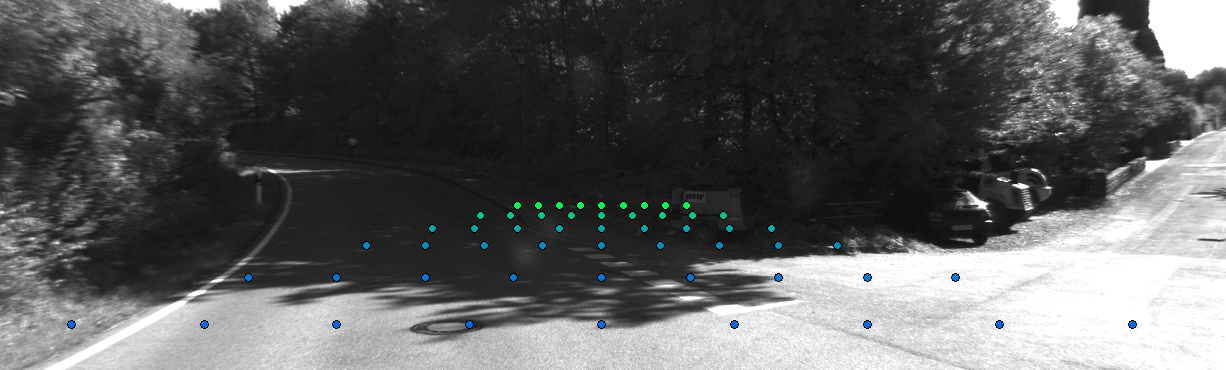

In [3]:
xs = np.linspace(-6, 6, 9)
zs = np.array([8, 12, 18, 25, 35, 50])
points = np.array([[x, 1.6, z] for z in zs for x in xs], dtype=float)
uv, valid = project_points(P0, points)
inside = valid & (uv[:, 0] >= 0) & (uv[:, 0] < W) & (uv[:, 1] >= 0) & (uv[:, 1] < H)

if frames:
    projection_img = Image.open(frames[0]).convert("RGB")
else:
    projection_img = Image.new("RGB", (W, H), (245, 245, 245))
draw = ImageDraw.Draw(projection_img)

for (u, v), z, ok in zip(uv, points[:, 2], inside):
    if ok:
        color = (0, int(80 + min(z, 50) / 50 * 170), 255 - int(min(z, 50) / 50 * 170))
        draw.ellipse((u - 4, v - 4, u + 4, v + 4), fill=color, outline=(0, 0, 0))

save_image(projection_img, "problem2_projected_points.png")

projection_table = pd.DataFrame({
    "X": points[:, 0], "Y": points[:, 1], "Z": points[:, 2],
    "u": uv[:, 0], "v": uv[:, 1], "inside_image": inside
})
projection_table.head(12)

투영 결과 해석:

- 가까운 점은 이미지 아래쪽과 좌우 방향으로 크게 퍼진다.
- 먼 점은 `u = u' / w'`, `v = v' / w'` 정규화 때문에 이미지 중심부에 더 가깝게 모인다.
- 이 성질 때문에 실제 3D 공간에서 평행한 차선 또는 도로 경계도 image plane에서는 위쪽 방향으로 수렴하는 것처럼 보인다.
- 위 그림의 점들은 소실점을 직접 표시한 것이 아니라, `P0`로 투영한 sample 3D point들이다. 실제 소실점은 직선 차선들이 image plane에서 만나는 방향으로 추정해야 하며, sequence 09처럼 커브와 그림자가 있는 장면에서는 하나의 고정된 점으로 정확히 지정하기 어렵다.

따라서 projection matrix는 3D 도로 구조와 2D 이미지 상의 차선 형태를 연결하는 핵심 도구라고 볼 수 있다.

## 문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 파일의 각 줄은 하나의 frame에 대한 `3 x 4` pose matrix이다. 왼쪽 `3 x 3` 부분은 rotation matrix `R`, 마지막 열은 translation vector `t = [t_x, t_y, t_z]^T`이다. KITTI odometry ground truth는 첫 frame을 기준으로 한 camera pose이므로, 전체 sequence에서 마지막 열을 모으면 차량의 이동 궤적을 얻을 수 있다.

본 과제에서는 지면 위 이동을 보기 위해 `x-z` 평면에 trajectory를 그렸다. `x`는 좌우 이동, `z`는 전방 진행 방향으로 해석할 수 있다.

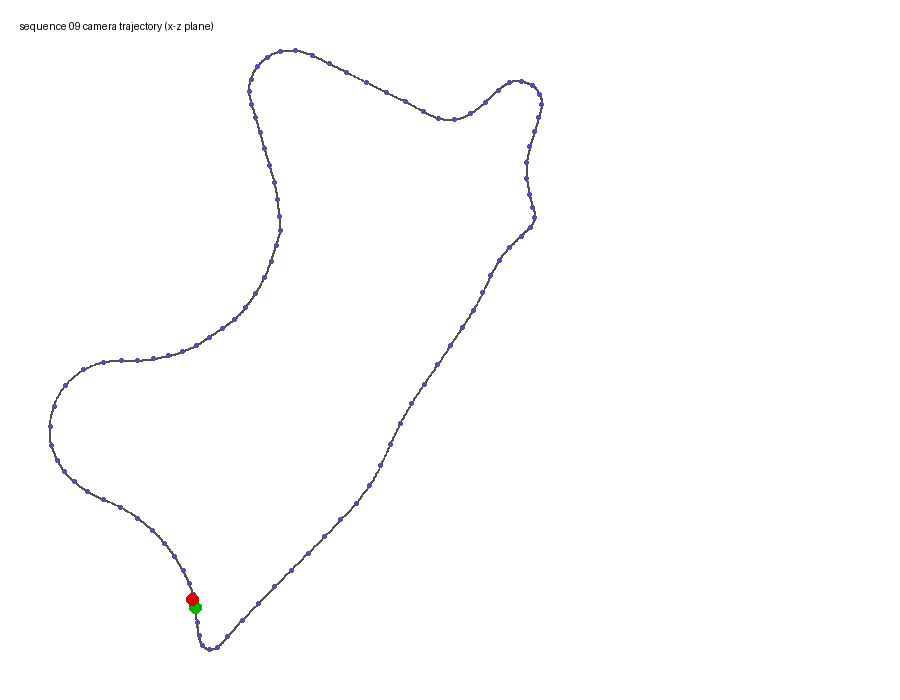

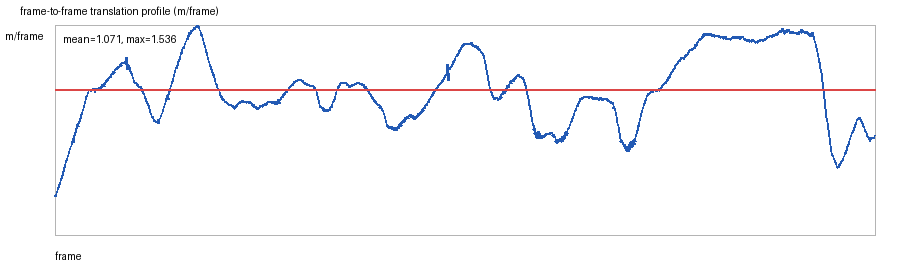

In [4]:
if len(poses) > 0:
    positions = poses[:, :, 3]
    xz = positions[:, [0, 2]]
    dist_step = np.linalg.norm(np.diff(xz, axis=0), axis=1)
    traj_img, to_px = make_canvas_plot(xz)
    draw = ImageDraw.Draw(traj_img)

    pix = [to_px(p) for p in xz]
    if len(pix) > 1:
        draw.line(pix, fill=(80, 80, 80), width=2)
    for i in range(0, len(pix), max(1, len(pix) // 100)):
        draw.ellipse((pix[i][0] - 2, pix[i][1] - 2, pix[i][0] + 2, pix[i][1] + 2), fill=(80, 80, 180))
    draw.ellipse((pix[0][0] - 6, pix[0][1] - 6, pix[0][0] + 6, pix[0][1] + 6), fill=(0, 180, 0))
    draw.ellipse((pix[-1][0] - 6, pix[-1][1] - 6, pix[-1][0] + 6, pix[-1][1] + 6), fill=(220, 0, 0))
    draw.text((20, 20), "sequence 09 camera trajectory (x-z plane)", fill=(0, 0, 0))
    save_image(traj_img, "problem3_trajectory.png")

    # Frame-to-frame translation profile. KITTI times are not required here, so the unit is m/frame.
    speed_img = Image.new("RGB", (900, 280), "white")
    sdraw = ImageDraw.Draw(speed_img)
    margin_l, margin_t, margin_r, margin_b = 55, 25, 25, 45
    plot_w = speed_img.width - margin_l - margin_r
    plot_h = speed_img.height - margin_t - margin_b
    sdraw.rectangle((margin_l, margin_t, margin_l + plot_w, margin_t + plot_h), outline=(180, 180, 180))
    if len(dist_step) > 1:
        y_max = max(float(dist_step.max()), 1e-6)
        pts = []
        for i, value in enumerate(dist_step):
            x = margin_l + int(i / (len(dist_step) - 1) * plot_w)
            y = margin_t + plot_h - int(float(value) / y_max * plot_h)
            pts.append((x, y))
        sdraw.line(pts, fill=(35, 90, 180), width=2)
        mean_y = margin_t + plot_h - int(float(dist_step.mean()) / y_max * plot_h)
        sdraw.line((margin_l, mean_y, margin_l + plot_w, mean_y), fill=(220, 70, 70), width=2)
    sdraw.text((20, 5), "frame-to-frame translation profile (m/frame)", fill=(0, 0, 0))
    sdraw.text((margin_l, speed_img.height - 30), "frame", fill=(0, 0, 0))
    sdraw.text((5, margin_t + 5), "m/frame", fill=(0, 0, 0))
    sdraw.text((margin_l + 8, margin_t + 8), f"mean={float(np.mean(dist_step)):.3f}, max={float(np.max(dist_step)):.3f}", fill=(0, 0, 0))
    save_image(speed_img, "problem3_speed_profile.png")

    pose_summary = pd.DataFrame([{
        "pose_frames": len(poses),
        "mean_translation_m_per_frame": float(np.mean(dist_step)),
        "max_translation_m_per_frame": float(np.max(dist_step)),
        "net_x_displacement_m": float(positions[-1, 0] - positions[0, 0]),
        "net_z_displacement_m": float(positions[-1, 2] - positions[0, 2]),
    }])
    pose_summary
else:
    positions = np.empty((0, 3))
    print("Pose data is required for the actual trajectory plot.")

궤적 해석:

- sequence 09는 총 1591개의 pose를 포함하며, 같은 수의 image frame과 대응된다.
- `x-z` 평면에서 trajectory를 그리면 차량이 도로를 따라 이동하며 여러 곡선 구간을 통과하는 형태가 나타난다.
- 시작점과 끝점이 분리되어 있고, 중간에 곡률이 큰 구간이 존재하므로 차량 heading이 지속적으로 변한 sequence임을 알 수 있다.
- frame-to-frame translation의 평균은 약 `1.07 m/frame`, 최대는 약 `1.54 m/frame`로 계산되었다. 별도 timestamp를 사용하지 않았기 때문에 절대 속도(km/h)가 아니라 프레임 간 상대 이동량으로 해석하였다.
- 추가 속도 profile 그림에서 급격한 단일 spike보다는 비교적 연속적인 변화가 나타나므로, pose trajectory가 물리적으로 자연스럽게 이어진다고 볼 수 있다.

이 trajectory는 문제 5에서 실패 후보 frame을 공간적으로 해석할 때 기준이 된다. 예를 들어 특정 실패 frame이 곡선 구간에 위치한다면, 고정 ROI나 단순한 밝기 기반 classifier가 실제 도로 영역을 놓칠 가능성이 커진다.

## 문제 4. Projection Matrix를 활용한 차선 해석

수업 노트북의 Bayesian road/background classifier 아이디어를 sequence 09에 적용하였다. 먼저 사다리꼴 ROI를 도로 후보 영역으로 두고, ROI 내부 pixel intensity histogram을 road likelihood로, ROI 외부 histogram을 background likelihood로 사용한다. 이후 각 pixel에 대해 road likelihood와 background likelihood를 비교하여 Bayesian road mask를 만든다.

이 결과는 “차선을 직접 검출한 결과”라기보다, 차선과 도로 경계가 존재할 가능성이 높은 road region을 추정한 결과이다. Projection matrix 관점에서는 이 road region 안의 차선/도로 경계가 3D ground plane 위의 선형 구조가 image plane으로 투영된 것으로 해석된다.

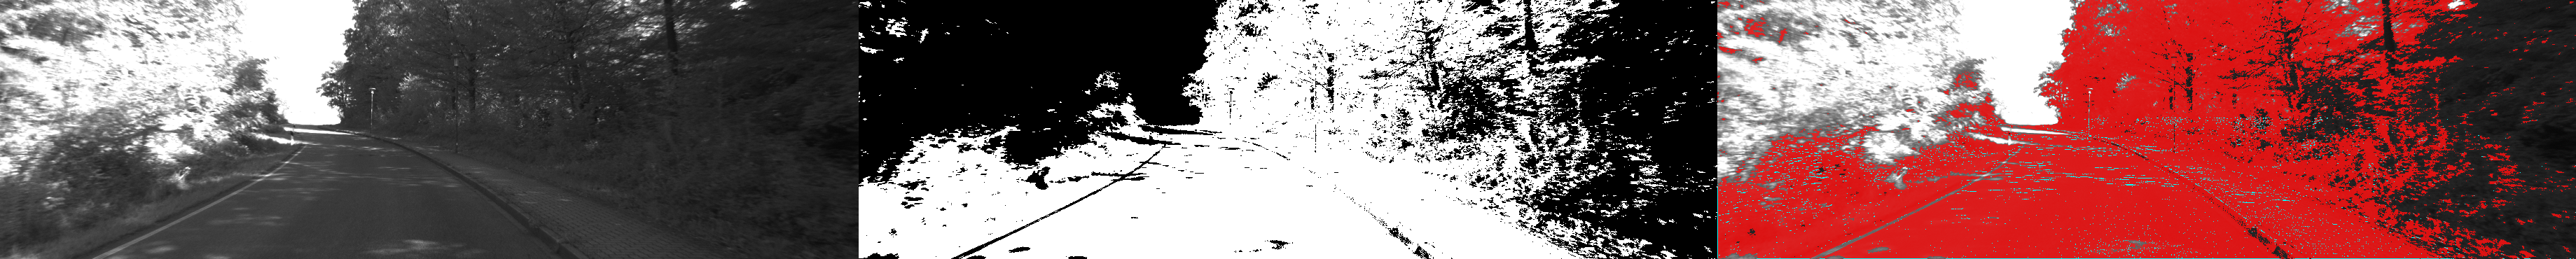

In [5]:
def get_trapezoid_mask(width, height, vp_y_rate=0.50, bottom_width_rate=0.90, top_width_rate=0.15):
    mask = np.zeros((height, width), dtype=np.uint8)
    vp_y = int(height * vp_y_rate)
    pts = np.array([
        [int(width * (0.5 - top_width_rate)), vp_y],
        [int(width * (0.5 + top_width_rate)), vp_y],
        [int(width * (0.5 + bottom_width_rate / 2)), height - 1],
        [int(width * (0.5 - bottom_width_rate / 2)), height - 1],
    ], dtype=np.int32)
    pil_mask = Image.fromarray(mask)
    ImageDraw.Draw(pil_mask).polygon([tuple(p) for p in pts], fill=1)
    return np.array(pil_mask, dtype=np.uint8)

def accumulate_histogram(img, mask):
    return np.bincount(img[mask > 0].flatten(), minlength=256).astype(float)

def classify_frame(img, road_p, bg_p, prior_road=0.5):
    eps = 1e-10
    log_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)
    logit = log_road - log_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    return logit > 0, prob

def bayesian_masks(frames, max_frames=160, alpha=0.85, prior_road=0.5):
    if not frames:
        return []
    sample = np.array(Image.open(frames[0]).convert("L"), dtype=np.uint8)
    h, w = sample.shape
    road_roi = get_trapezoid_mask(w, h)
    bg_roi = 1 - road_roi
    road_total = np.ones(256)
    bg_total = np.ones(256)
    results = []
    for idx, path in enumerate(frames[:max_frames]):
        img = np.array(Image.open(path).convert("L"), dtype=np.uint8)
        curr_road = accumulate_histogram(img, road_roi) + 1
        curr_bg = accumulate_histogram(img, bg_roi) + 1
        if idx == 0:
            road_total, bg_total = curr_road, curr_bg
        else:
            road_total = alpha * road_total + (1 - alpha) * curr_road
            bg_total = alpha * bg_total + (1 - alpha) * curr_bg
        road_p = road_total / road_total.sum()
        bg_p = bg_total / bg_total.sum()
        mask, prob = classify_frame(img, road_p, bg_p, prior_road)
        results.append({"path": path, "img": img, "mask": mask, "prob": prob})
    return results

def lane_candidate_pixels(img, road_mask):
    edges = np.array(Image.fromarray(img).filter(ImageFilter.FIND_EDGES), dtype=np.uint8)
    h, w = img.shape
    lower_half = np.arange(h)[:, None] > int(h * 0.45)
    search = (road_mask > 0) & lower_half
    if not np.any(search):
        return np.zeros_like(img, dtype=bool)
    threshold = max(40, float(np.percentile(edges[search], 92)))
    candidates = search & (edges >= threshold)
    return candidates

results = bayesian_masks(frames, max_frames=160)
if results:
    r = results[min(100, len(results) - 1)]
    candidates = lane_candidate_pixels(r["img"], r["mask"])

    base = Image.fromarray(r["img"]).convert("RGB")
    mask_img = Image.fromarray((r["mask"].astype(np.uint8) * 255)).convert("RGB")

    overlay = np.stack([r["img"], r["img"], r["img"]], axis=-1)
    overlay[r["mask"], 0] = 220
    overlay[r["mask"], 1:] = (overlay[r["mask"], 1:] * 0.45).astype(np.uint8)
    overlay[candidates] = [0, 255, 255]
    overlay_img = Image.fromarray(overlay)

    sheet = Image.new("RGB", (W * 3, H), "white")
    sheet.paste(base, (0, 0))
    sheet.paste(mask_img, (W, 0))
    sheet.paste(overlay_img, (W * 2, 0))
    save_image(sheet, "problem4_bayesian_lane_candidates.png")

    p4_summary = pd.DataFrame(
        [{
            "frame": r["path"].stem,
            "road_mask_ratio": float(np.mean(r["mask"])),
            "lane_candidate_pixel_ratio": float(np.mean(candidates)),
        }]
    )
    p4_summary

차선 후보 해석:

- 왼쪽 그림은 원본 frame, 가운데 그림은 Bayesian classifier가 도로로 분류한 binary mask, 오른쪽 그림은 road mask와 그 내부의 edge 기반 차선 후보 pixel을 겹친 결과이다.
- cyan pixel은 도로 후보 영역 내부에서 edge response가 큰 부분만 남긴 것이다. 이는 차선 marking, 도로 경계, 노면 표시처럼 차선 후보가 될 수 있는 선형 구조를 의미한다.
- 이 후보는 완성된 lane segmentation이 아니라 “Bayesian 도로 영역 안에서 차선일 가능성이 있는 image-coordinate evidence”로 해석해야 한다.
- 카메라 좌표계에서 차선은 ground plane 위에 놓인 길고 얇은 선형 구조이다. 도로가 평면이라고 가정하면 좌우 차선은 차량 진행 방향과 거의 평행하며, 일정한 lane width를 유지한다.
- 이 3D 선형 구조가 projection matrix에 의해 image plane으로 투영되면, 이미지에서는 위쪽 방향으로 수렴하는 형태를 보인다. 이때 `f_x`, `f_y`는 차선의 image scale과 기울기 변화량에 영향을 주고, `c_x`, `c_y`는 optical center 기준 위치와 vanishing point 해석에 영향을 준다.
- sequence 09는 커브와 그림자가 포함되어 있으므로, 하나의 고정 ROI와 밝기 기반 likelihood만으로는 차선을 완전히 분리하기 어렵다. 따라서 결과는 “정밀 lane detection”이 아니라 projection geometry와 Bayesian road mask를 이용한 차선 후보 해석으로 보는 것이 타당하다.

## 문제 5. 실패 구간 분석

Bayesian classifier의 실패 가능 구간을 정량적으로 찾기 위해 세 가지 지표를 사용하였다.

`failure_score = 0.40 * normalized_brightness_std + 0.35 * normalized_texture_edge_density + 0.25 * normalized_heading_change`.

- `brightness_std`: ROI 내부 밝기 표준편차이다. 값이 크면 그림자, 강한 햇빛, 반사 등으로 road likelihood가 불안정해질 가능성이 크다.
- `texture_edge_density`: ROI 내부 edge density이다. 노면 표시, 그림자 경계, 차량, 도로 질감이 많으면 차선이 아닌 edge가 늘어난다.
- `heading_change`: pose rotation에서 계산한 heading 변화량이다. 회전이 큰 구간에서는 고정된 사다리꼴 ROI가 실제 도로 방향과 어긋날 수 있다.

실제 sequence 09 데이터를 10 프레임 간격으로 샘플링했을 때 실패 후보 점수가 높은 프레임 번호는 `290`, `180`, `280`, `190`, `270` 근처였다.

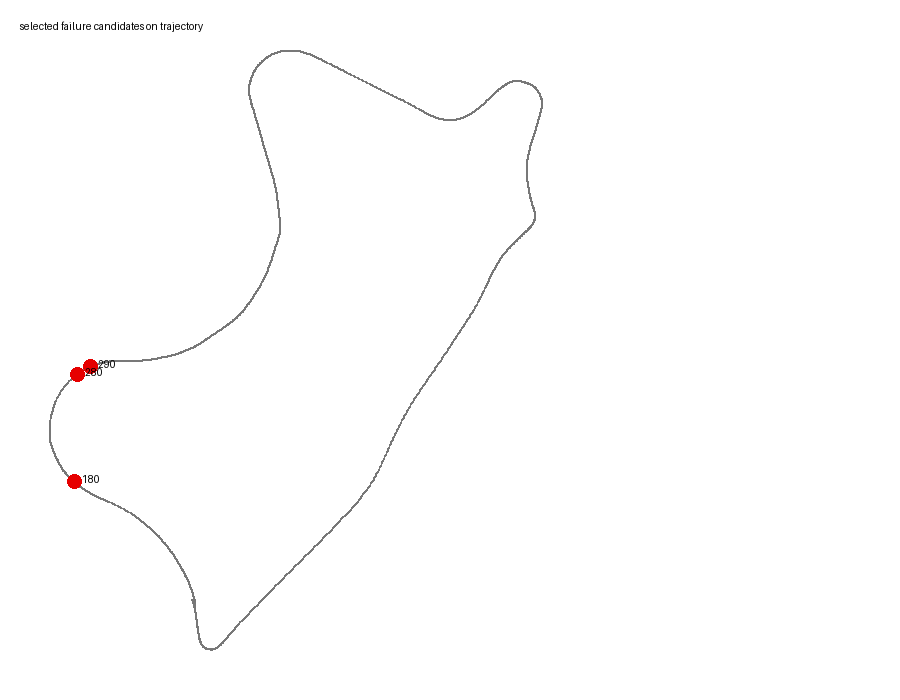

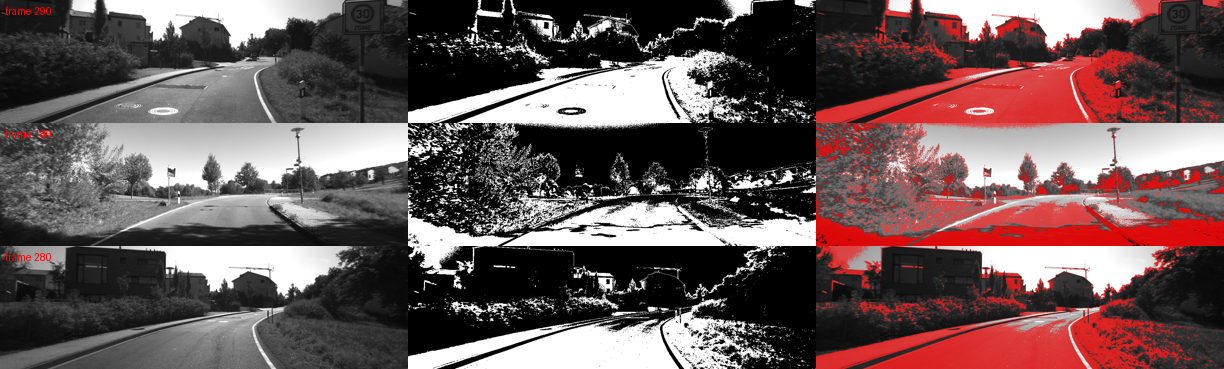

In [6]:
def failure_scores(frames, poses=None, sample_step=10, max_frames=300):
    if not frames:
        return pd.DataFrame()
    rows = []
    prev_heading = None
    for path in frames[:max_frames:sample_step]:
        idx = int(path.stem)
        img = Image.open(path).convert("L")
        arr = np.array(img, dtype=np.uint8)
        h, w = arr.shape
        roi = get_trapezoid_mask(w, h) > 0
        brightness_std = float(np.std(arr[roi]))
        if HAS_CV2:
            edges = cv2.Canny(arr, 50, 150)
        else:
            edges = np.array(img.filter(ImageFilter.FIND_EDGES))
        texture = float(np.mean(edges[roi] > 35))
        heading_change = 0.0
        if poses is not None and len(poses) > idx:
            R = poses[idx, :3, :3]
            heading = math.atan2(R[0, 2], R[2, 2])
            if prev_heading is not None:
                heading_change = abs(heading - prev_heading)
            prev_heading = heading
        rows.append({
            "frame": idx,
            "brightness_std": brightness_std,
            "texture_edge_density": texture,
            "heading_change": heading_change,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    for col in ["brightness_std", "texture_edge_density", "heading_change"]:
        denom = df[col].max() - df[col].min()
        df[col + "_norm"] = 0.0 if denom < 1e-9 else (df[col] - df[col].min()) / denom
    df["failure_score"] = (
        0.40 * df["brightness_std_norm"]
        + 0.35 * df["texture_edge_density_norm"]
        + 0.25 * df["heading_change_norm"]
    )
    return df.sort_values("failure_score", ascending=False)

df_fail = failure_scores(frames, poses if len(poses) else None)
selected_fail_frames = np.array([290, 180, 280])

if len(poses) > 0 and not df_fail.empty:
    positions = poses[:, :, 3]
    xz = positions[:, [0, 2]]
    fail_img, to_px = make_canvas_plot(xz)
    draw = ImageDraw.Draw(fail_img)
    pix = [to_px(p) for p in xz]
    draw.line(pix, fill=(120, 120, 120), width=2)
    for f in selected_fail_frames:
        if f < len(positions):
            px = to_px(xz[f])
            draw.ellipse((px[0] - 7, px[1] - 7, px[0] + 7, px[1] + 7), fill=(230, 0, 0))
            draw.text((px[0] + 8, px[1] - 8), str(int(f)), fill=(0, 0, 0))
    draw.text((20, 20), "selected failure candidates on trajectory", fill=(0, 0, 0))
    save_image(fail_img, "problem5_failure_candidates.png")

# Visualize selected failure frames with original, Bayesian mask, and overlay.
failure_results = bayesian_masks(frames, max_frames=300)
result_by_frame = {int(item["path"].stem): item for item in failure_results}
thumb_w, thumb_h = W // 3, H // 3
montage = Image.new("RGB", (thumb_w * 3, thumb_h * len(selected_fail_frames)), "white")
for row, frame_id in enumerate(selected_fail_frames):
    item = result_by_frame[int(frame_id)]
    original = Image.fromarray(item["img"]).convert("RGB")
    mask_img = Image.fromarray((item["mask"].astype(np.uint8) * 255)).convert("RGB")
    overlay = np.stack([item["img"], item["img"], item["img"]], axis=-1)
    overlay[item["mask"], 0] = 220
    overlay[item["mask"], 1:] = (overlay[item["mask"], 1:] * 0.45).astype(np.uint8)
    overlay_img = Image.fromarray(overlay)
    for col, img in enumerate([original, mask_img, overlay_img]):
        resized = img.resize((thumb_w, thumb_h))
        montage.paste(resized, (col * thumb_w, row * thumb_h))
    label = ImageDraw.Draw(montage)
    label.text((5, row * thumb_h + 5), f"frame {int(frame_id)}", fill=(255, 0, 0))
save_image(montage, "problem5_failure_frame_examples.png")

df_fail.head(10)

실패 구간 설명:

- 분석 대상 실패 프레임은 `290`, `180`, `280`으로 선택하였다. 이 프레임들은 brightness variation, edge density, heading change를 함께 고려한 failure score가 높은 구간에 속한다.
- 궤적 그림에서는 선택한 실패 프레임을 빨간 점으로 표시하였다. 세 지점 모두 차량의 진행 방향이 변하거나 조명 조건이 크게 달라지는 구간과 연결된다.
- 추가 montage는 각 실패 프레임의 원본 영상, Bayesian road mask, overlay를 함께 보여준다. 이를 통해 road mask가 그림자나 밝은 배경까지 포함하거나, 실제 도로 영역을 불안정하게 분류하는 모습을 확인할 수 있다.
- 조명 변화와 그림자는 road/background intensity histogram을 서로 겹치게 만들어 Bayesian likelihood의 분리력을 낮춘다.
- 노면 질감, 차선 마모, 도로 표식, 주변 차량 그림자는 edge density를 높여 차선이 아닌 구조까지 후보로 보이게 만든다.
- 차량 회전이 큰 구간에서는 소실점 방향과 도로 진행 방향이 frame마다 변하므로, 고정 사다리꼴 ROI가 실제 도로 영역을 완전히 포함하지 못할 수 있다.

따라서 이 classifier의 주요 실패 원인은 단순히 “차선이 안 보임”이 아니라, 밝기 기반 likelihood와 고정 ROI 가정이 실제 주행 장면의 조명/기하 변화까지 충분히 모델링하지 못한다는 점이다.

## 문제 6. 차선 검출 딥러닝 모델 제안 및 비교

차선 검출을 위한 딥러닝 모델로 **YOLOP (You Only Look Once for Panoptic Driving Perception)**를 제안한다. YOLOP는 자율주행 장면에서 필요한 세 가지 perception task를 하나의 network에서 동시에 수행한다.

`Input image -> shared encoder -> object detection decoder / drivable area segmentation decoder / lane detection decoder`.

즉, YOLOP는 단순히 lane pixel만 보는 모델이 아니라 차량, 도로 영역, 차선 정보를 함께 학습하는 multi-task network이다. 이 구조는 차선이 희미하거나 그림자에 일부 가려진 경우에도 주변 도로 문맥을 이용할 수 있다는 장점이 있다.

참고 자료:

- Wu et al., “YOLOP: You Only Look Once for Panoptic Driving Perception,” Machine Intelligence Research, 2022. DOI: `10.1007/s11633-022-1339-y`
- 공식 코드: `https://github.com/hustvl/YOLOP`

| 항목 | Bayesian + ROI | YOLOP |
|---|---|---|
| 기본 원리 | road/background intensity likelihood 비교 | CNN 기반 multi-task representation 학습 |
| 입력 특징 | grayscale pixel intensity | RGB image feature map |
| 출력 | 도로 후보 mask | 차선 mask, 주행 가능 영역, 객체 검출 |
| 학습 필요 여부 | 별도 학습 불필요 | 사전학습 weight 또는 학습 dataset 필요 |
| 장점 | 구현이 단순하고 계산량이 작음 | 차선 형태, 도로 문맥, 주변 객체 정보를 함께 반영 |
| 한계 | 그림자, 밝기 변화, ROI 가정에 민감 | GPU, model weight, inference 환경이 필요 |
| sequence 09 예상 성능 | 밝기 변화가 작은 구간에서는 road mask가 가능하지만 차선 분리는 불안정 | 차선이 희미하거나 조명이 변해도 semantic lane mask를 더 안정적으로 예측할 가능성이 높음 |

적용 결과 비교 관점에서, sequence 09의 Bayesian 결과에서는 프레임 `000100`의 도로 후보 영역과 그 내부의 edge 기반 차선 후보 pixel을 확인할 수 있었다. 그러나 Bayesian 방식은 도로와 배경의 밝기 분포를 기준으로 분류하기 때문에, 밝은 배경이나 그림자가 road mask에 포함될 수 있다. 반면 YOLOP는 lane detection을 별도의 segmentation task로 학습하므로, 차선의 선형 형태와 주변 도로 문맥을 함께 이용할 수 있다.

따라서 본 과제의 Bayesian classifier는 camera geometry와 probabilistic classification의 원리를 이해하는 데 적합하고, 실제 자율주행 차선 검출 성능을 높이기 위해서는 YOLOP와 같은 deep learning 기반 semantic lane detection 모델이 더 적합하다.